In [3]:
import pandas as pd
df=pd.read_csv("credit_risk_data.csv")
df.head()


,ID_Cliente,Ingreso_Mensual,Tipo_Vivienda,Mora_Previa,Estado_Credito,Puntaje_Psicometrico
0,FT-00001,2.21,Propia,0,0,72
1,FT-00002,2.49,Alquilada,0,1,33
2,FT-00003,5.65,Propia,0,0,63
3,FT-00004,3.82,Alquilada,0,0,71
4,FT-00005,5.08,Alquilada,1,0,59


## **Parte I: Diagnóstico de Cartera y Comportamiento del Cliente**
### **Pregunta 1: Segmentación de Vivienda e Inestabilidad**
**1.** ¿Qué tan representativo es el grupo de clientes que viven en arriendo pero que logran cumplir con sus obligaciones financieras respecto al total de la cartera?

**A =** Cliente que vive en arriendo.   
**C =** Cliente que cumple con sus obligaciones financieras.

**P(A ∩ C) =** 0.2913  **-** 29.13%

El grupo de clientes que viven en arriendo pero que logran cumplir con sus obligaciones financieras representan el 29.13% de los clientes

In [26]:
p_ac= len(df[(df["Tipo_Vivienda"] == "Alquilada") & (df["Estado_Credito"] == 0)]) / len(df)
p_ac

0.2913

**2.** ¿Qué proporción de la base de datos total está compuesta por clientes que  alquilan su vivienda y además presentan un estado de default?

**A =** Cliente que vive en arriendo.   
**D =** Cliente en estado de default.

**P(A ∩ D) =** 0.0769 **-** 7.69%

El grupo de clientes que viven en arriendo y se encuentran en estado de default representan el 7.69% de los clientes




**Reflexión:** Si usted fuera el director de estrategia, ¿consideraría que el hecho de vivir en arriendo es un indicador suficiente para denegar un crédito de forma automática? Utilice los valores obtenidos para sustentar su postura.   
**R/.** No, ya que la proporción de clientes que viven en arriendo y cumplen con sus obligaciones financieras (29.13%) es significativamente mayor que la de aquellos que viven en arriendo y presentan estado de default (7.69%). Esto indica que, aunque existe un grupo de arrendatarios con incumplimiento, la mayoría de los clientes que alquilan vivienda mantienen un comportamiento crediticio adecuado, por lo que no sería apropiado considerar a todos los arrendatarios como clientes de alto riesgo.

### **Pregunta 2: El Peso del Pasado**
**1.** Si seleccionamos al azar a un cliente que sabemos que tiene antecedentes de mora (Mora Previa = 1), ¿cuál es la probabilidad de que este cliente termine efectivamente en default en su crédito actual?

**D =** Clientes en estado de default.   
**M =** Clientes con antecedentes de mora.

**P(D | M)** = P(D ∩ M) / P(M)   
**P(D | M)** = 0.0629 / 0.1198   
**P(D | M)** = 0.5250417362270451 **-** 52.50%

La probabilidad de que un cliente con antecedentes de mora termine en default en su crédito actual es de 52.50%



In [28]:
p_dm = len(df[(df["Mora_Previa"] == 1) & (df["Estado_Credito"] == 1)]) / len(df)
p_m = len(df[df["Mora_Previa"] == 1]) / len(df)
p_dm / p_m

0.5250417362270451

**2.** Compare este resultado con la probabilidad de default de un cliente del que no tenemos información previa de mora.   

**D =** Clientes en estado de default.   
**S =** Clientes sin antecedentes de mora.

**P(D | S) =** P(D ∩ S) / P(S)  
**P(D | S) =** 0.0474 / 0.8802   
**P(D | S) =** 0.05385139740967962 - 5.38%  

La probabilidad de que un cliente sin antecedentes de mora termine en default en su crédito actual es de 5.38%

In [29]:
p_ds = len(df[(df["Mora_Previa"] == 0) & (df["Estado_Credito"] == 1)]) / len(df)
p_s = len(df[df["Mora_Previa"] == 0]) / len(df)
p_ds / p_s

0.05385139740967962

**Reflexión:** ¿Es la Mora Previa un predictor determinante o un distractor estadístico? ¿Cómo cambia su percepción del riesgo de un solicitante cuando este antecedente entra en la ecuación?   
**R/.** Sí, la mora previa es un predictor determinante del riesgo de default, ya que la probabilidad de incumplimiento para clientes con antecedentes de mora (52.50%) es significativamente mayor que para aquellos sin mora previa (5.38%). Esta diferencia tan marcada indica que la presencia de mora previa aumenta considerablemente el riesgo de incumplimiento en el crédito actual. Por lo tanto, cuando este antecedente entra en la evaluación, la percepción del riesgo del solicitante cambia de manera drástica: un cliente con historial de mora debe ser considerado significativamente más riesgoso que uno que no presenta este antecedente.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pregunta 3: El dilema del Analista

Para resolver este problema desde una perspectiva bayesiana haremos lo siguiente.  
Queremos conocer la probabilidad de que un cliente tenga antecedentes de mora dado que está en un estado de default, invirtiendo nuestro pensamiento habitual de causa y efecto. Ahora queremos saber qué tan probable es que la causa sea que ya estuvo en mora, dado que observamos el efecto de que está en default.

$$
P(\text{Causa} \mid \text{Efecto}) = \frac{P(\text{Efecto} \mid \text{Causa}) \cdot P(\text{Causa})}{P(\text{Efecto})}
$$

También necesitamos tener en cuenta el cálculo de la probabilidad condicional:

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

In [33]:
data = pd.read_csv('credit_risk_data.csv')
P_mora = np.sum(data['Mora_Previa']) / len(data)
print(f'Probabilidad de Mora Previa: {P_mora:.4f}')
P_default = np.sum(data['Estado_Credito']) / len(data)
print(f'Probabilidad de Default: {P_default:.4f}')
P_default_dada_mora = (len(data[(data['Mora_Previa'] == 1) & (data['Estado_Credito'] == 1)]) / len(data))
print(f'Probabilidad de Default dado Mora: {P_default_dada_mora:.4f}')
P_mora_dado_default = (P_default_dada_mora * P_mora) / P_default
print(f'Probabilidad de Mora dado Default: {P_mora_dado_default:.4f}')


Probabilidad de Mora Previa: 0.1198
Probabilidad de Default: 0.1103
Probabilidad de Default dado Mora: 0.0629
Probabilidad de Mora dado Default: 0.0683


**Conclusión:** Al aplicar el Teorema de Bayes, comprobamos que el 57% de los clientes que caen en default tienen antecedentes de mora. Esto responde a la pregunta inicial: sí, la mayoría de los incumplimientos provienen de clientes reincidentes. Sin embargo, un 43% de los clientes en default tenía un historial limpio de mora, lo que demuestra que existen factores externos que también tienen un gran impacto en el incumplimiento de los créditos.

## Pregunta 4: Modelado de Ingreso Mensual (X)
### **1.** Estime el valor esperado E[X] y la varianza V ar(X) de los ingresos de la cartera total. ¿Qué nos dice la diferencia entre la media y la mediana sobre la equidad de los ingresos en esta muestra?

In [ ]:
E_ingreso = data['Ingreso_Mensual'].mean()
print(f'Valor esperado del Ingreso Mensual: {E_ingreso:.2f}')
V_ingreso = data['Ingreso_Mensual'].var()
print(f'Varianza del Ingreso Mensual: {V_ingreso:.2f}')
print(f'Mediana del Ingreso Mensual: {data["Ingreso_Mensual"].median():.2f}')

Valor esperado del Ingreso Mensual: 3.92
Varianza del Ingreso Mensual: 2.09
Mediana del Ingreso Mensual: 3.77


El valor esperado al ser una base de datos y no tener una función de distribución de
probabilidad lo calcule como la media. De la diferencia entre media y la mediana podemos
ver que nuestros datos efectivamente están sesgados hacia la derecha, ya que la media en
muy sensible a valores anormalmente grandes, que es exactamente lo que tenemos.


![Texto alternativo](Grafica.png)

### **2.** Suponiendo que el ingreso sigue una distribución continua, aproxime la probabilidad de que un solicitante elegido al azar tenga un ingreso entre 3.0 y 5.0 mil USD

In [36]:
P_betwenn_3_5 = np.sum((data['Ingreso_Mensual'] >= 3.0) & (data['Ingreso_Mensual'] <= 5.0)) / len(data)
print(f'Probabilidad de Ingreso entre 3 y 5 mil USD: {P_betwenn_3_5:.4f}')


Probabilidad de Ingreso entre 3 y 5 mil USD: 0.5108


### **3.** La empresa desea lanzar un producto “Premium” dirigido exclusivamente al 15 % de los clientes con mayores ingresos. ¿A partir de qué monto de ingreso mensual debería enviarse la invitación a este producto?.

In [37]:
umbral_premium = data['Ingreso_Mensual'].quantile(0.85)
print(f'Deberia enviarse una invitación a clientes con ingreso mensual superior a {umbral_premium:.2f} USD')
print(data['Ingreso_Mensual'].quantile(0.5))

Deberia enviarse una invitación a clientes con ingreso mensual superior a 5.41 USD
3.77


Respondiendo a la reflexión yo creo que que lo más apropiado para la empresa es basarse
en los quantiles, que no son sesgados por el poco número de clientes que tiene unos
ingresos muy superiores, ya que con el uso de estos se puede dar una mejor idea de los
clientes promedios y no las pocas excepciones con muchos ingresos.

##  Pregunta 5: Análisis de Separabilidad mediante Puntaje Psicométrico (S)


Estimar y graficar las funciones de densidad de probabilidad (PDF) del puntaje (S) condicionadas al estado del crédito.

Específicamente, se deben estimar las siguientes densidades condicionales:



* (S) representa el **puntaje de la prueba Psicométrica**.
* (C) representa el **estado del crédito**.
* (C = 0) indica **crédito no incumplido**.
* (C = 1) indica **crédito en incumplimiento (default)**.

El objetivo es comparar cómo se distribuye el puntaje de crédito para cada estado del crédito.


In [8]:
ClientesPagaron=df[df["Estado_Credito"]==0]["Puntaje_Psicometrico"]
ClientesNoPagaron=df[df["Estado_Credito"]==1]["Puntaje_Psicometrico"]

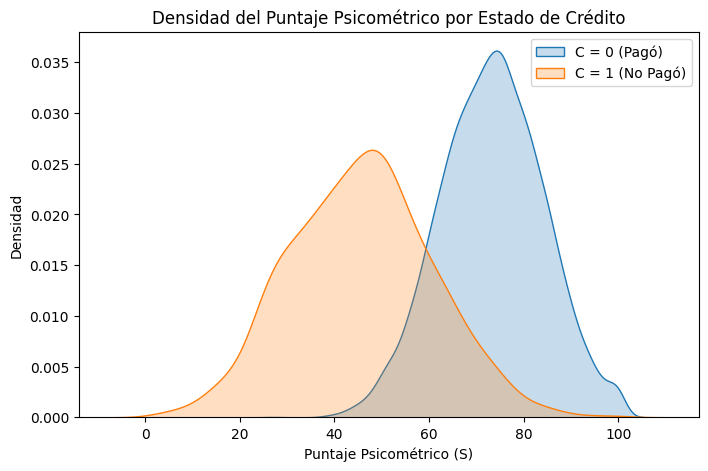

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(ClientesPagaron, label="C = 0 (Pagó)", fill=True)
sns.kdeplot(ClientesNoPagaron, label="C = 1 (No Pagó)", fill=True)

plt.xlabel("Puntaje Psicométrico (S)")
plt.ylabel("Densidad")
plt.title("Densidad del Puntaje Psicométrico por Estado de Crédito")
plt.legend()
plt.show()

### 2. Punto de intersección de las densidades

De forma visual podemos identificar que el punto de intersección es aproximadamente (60, 0.015) ahora ¿Qué significado tiene este punto
en términos de probabilidad de clasificación errónea?

El punto de intersección puede interpretarse como una zona de ambigüedad, ya que en ese valor del puntaje psicométrico se encuentran tanto clientes que pagaron como clientes que entraron que no pagaron. En este caso, alrededor de un puntaje cercano a 60, el test no permite diferenciar con claridad entre un cliente confiable y uno no confiable.

Por esta razón, en esa región aumenta la probabilidad de clasificación errónea. Por ejemplo, si la empresa decide que todos los clientes con puntaje menor o igual a 60 deben ser rechazados, existe el riesgo de excluir clientes que en realidad sí habrían pagado. De manera inversa, si se clasifica como confiables a los clientes con puntajes superiores a ese valor, también podría aceptarse a algunos que finalmente entren en default.

En consecuencia, cualquier decisión tomada cerca de ese umbral implica un riesgo de error.



### 3. Probabilidad de que un cliente que sí entró en default tenga un puntaje mayor a 60.


In [38]:
ClientesNoPagaron=df[df["Estado_Credito"]==1]["Puntaje_Psicometrico"]
probabilidad=len(ClientesNoPagaron[ClientesNoPagaron>60])/len(ClientesNoPagaron)

print(f"La probabilidad de que un cliente que sí entró en default tenga un puntaje mayor a 60 es de {probabilidad*100}%")

La probabilidad de que un cliente que sí entró en default tenga un puntaje mayor a 60 es de 16.59111514052584%


# Reflexión:
Si las dos funciones de densidad se solapan significativamente, el test psicométrico tiene una utilidad limitada para predecir el default, ya que no logra separar con claridad a los clientes que pagaron de aquellos que incumplieron. En ese caso, un mismo rango de puntajes puede corresponder a ambos grupos, lo que incrementa la probabilidad de clasificación errónea.

Sí, sería preferible un test en el que las medias de ambas densidades estén más alejadas entre sí, porque esto indicaría una mayor separación entre los grupos. Cuanto más distantes estén las distribuciones, mayor será la capacidad del test para discriminar entre clientes confiables y clientes con mayor riesgo de default.